In [ ]:
!pip install -U transformers
!pip install -U accelerate
!pip install -U datasets
!pip install -U bertviz
!pip install -U umap-learn
!pip install -U sentencepiece
!pip install --upgrade urllib3
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 13.5 MB/s eta 0:00:00
 

In [ ]:

from datasets import get_dataset_config_names
configs = get_dataset_config_names("cnn_dailymail")
print(configs)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

['1.0.0', '2.0.0', '3.0.0']


In [ ]:
from datasets import load_dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")

train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

In [ ]:
dataset['train'][1]['article'][:300]

'Editor\'s note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and analyze the stories behind the events. Here, Soledad O\'Brien takes users inside a jail where many of the inmates are mentally ill. An inmate housed on the "forgotten floor," where many men'

In [ ]:
dataset['train'][1]['highlights']

'Mentally ill inmates in Miami are housed on the "forgotten floor"\nJudge Steven Leifman says most are there as a result of "avoidable felonies"\nWhile CNN tours facility, patient shouts: "I am the son of the president"\nLeifman says the system is unjust and he\'s fighting for change .'

In [ ]:
#we will use gpt2,t5,bart,pegasus

In [ ]:
from transformers import pipeline
pipe=pipeline("text-generation",model="gpt2-medium")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
input_text=dataset['train'][1]['article'][:2000]
query=input_text + "\nTL;DR:\n"
pipe_out=pipe(query,max_length=512,clean_up_tokenization_spaces=True)


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
print(pipe_out[0]['generated_text'])

Editor's note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and analyze the stories behind the events. Here, Soledad O'Brien takes users inside a jail where many of the inmates are mentally ill. An inmate housed on the "forgotten floor," where many mentally ill inmates are housed in Miami before trial. MIAMI, Florida (CNN) -- The ninth floor of the Miami-Dade pretrial detention facility is dubbed the "forgotten floor." Here, inmates with the most severe mental illnesses are incarcerated until they're ready to appear in court. Most often, they face drug charges or charges of assaulting an officer --charges that Judge Steven Leifman says are usually "avoidable felonies." He says the arrests often result from confrontations with police. Mentally ill people often won't do what they're told when police arrive on the scene -- confrontation seems to exacerbate their illness and they become more paranoid, delusional, and less likely to follow dir

In [ ]:
pipe_out[0]['generated_text'][len(query):]

'- Most of the people in detention are mentally ill.\n- There is no physical protection from police.\n- The most severe cases are housed here.\n- About 1 out of 10 mentally ill people in Miami-Dade county jails are locked up in the basement.\n-\n- There have been at least 100 inmate deaths in county jails since 2009, according to records obtained'

In [ ]:
summaries={}
summaries['gpt2-medium-380M']=pipe_out[0]['generated_text'][len(query):]

In [ ]:
pipe=pipeline("summarization",model="t5-base")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
pipe_out=pipe(input_text)

In [ ]:
pipe_out[0]

{'summary_text': 'mentally ill inmates housed on the "forgotten floor" of a pretrial detention facility in florida . inmates with the most severe mental illnesses are incarcerated until they\'re ready to appear . a judge says the arrests often result from confrontations with police . mentally ill people often won\'t do what police say, judge says .'}

In [ ]:
#gpt naturally prints the query+summary whereas t5 prints summar only

In [ ]:
summaries['t5-base-223M']=pipe_out[0]['summary_text']

In [ ]:
# pipe=pipeline("summarization",model='facebook/bart-large-cnn')
# pipe_out=pipe(input_text)

In [ ]:
# summaries['bart-large-cnn-400M']=pipe_out[0]['summary_text']

In [ ]:
# pipe=pipeline('summarization',model='google/pegasus-cnn_dailymail')

In [ ]:
# pipe_out=pipe(input_text)

In [ ]:
# summaries['pegasus-cnn-568M']=pipe_out[0]['summary_text']

In [ ]:
for model in summaries:
  print(model.upper())
  print(summaries[model])
  print("")


GPT2-MEDIUM-380M
- Most of the people in detention are mentally ill.
- There is no physical protection from police.
- The most severe cases are housed here.
- About 1 out of 10 mentally ill people in Miami-Dade county jails are locked up in the basement.
-
- There have been at least 100 inmate deaths in county jails since 2009, according to records obtained

T5-BASE-223M
mentally ill inmates housed on the "forgotten floor" of a pretrial detention facility in florida . inmates with the most severe mental illnesses are incarcerated until they're ready to appear . a judge says the arrests often result from confrontations with police . mentally ill people often won't do what police say, judge says .



In [ ]:
from datasets import load_dataset
from transformers import pipeline
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

In [ ]:
device='gpu'
model_ckpt='facebook/bart-large-cnn'
tokenizer=AutoTokenizer.from_pretrained(model_ckpt)
model=AutoModelForSeq2SeqLM.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

In [ ]:
samsum=load_dataset('samsum')

README.md:   0%|          | 0.00/7.04k [00:00<?, ?B/s]

samsum.py:   0%|          | 0.00/3.36k [00:00<?, ?B/s]

The repository for samsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/samsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


corpus.7z:   0%|          | 0.00/2.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

In [ ]:
samsum

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14732
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
})

In [ ]:
samsum['train'][0]

{'id': '13818513',
 'dialogue': "Amanda: I baked  cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)",
 'summary': 'Amanda baked cookies and will bring Jerry some tomorrow.'}

In [ ]:
dialogue_len=[len(x['dialogue'].split()) for x in samsum['train']]
summary_len=[len(x['summary'].split()) for x in samsum['train']]

In [ ]:
import pandas as pd
data=pd.DataFrame([dialogue_len,summary_len]).T
data.columns=['Dialogue Length','Summary Length']
data.head()

,Dialogue Length,Summary Length
0,16,9
1,18,10
2,98,14
3,26,18
4,179,27


array([[<Axes: title={'center': 'Dialogue Length'}>,
        <Axes: title={'center': 'Summary Length'}>]], dtype=object)

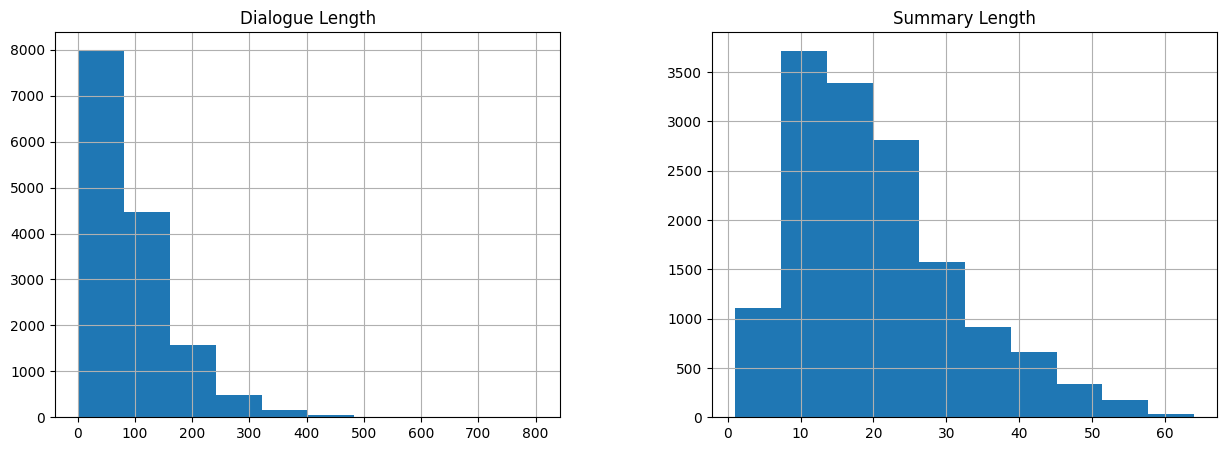

In [ ]:
data.hist(figsize=(15,5))

In [ ]:
#buildng data collator
def get_feature(batch):
  encodings=tokenizer(batch['dialogue'],text_target=batch['summary'],
                      max_length=1024,truncation=True)
  encodings={'input_ids':encodings['input_ids'],
             'attention_mask':encodings['attention_mask'],
             'labels':encodings['labels']}
  return encodings


In [ ]:
samsum_pt=samsum.map(get_feature,batched=True)

Map:   0%|          | 0/14732 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

In [ ]:
samsum_pt

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 14732
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
})

In [ ]:
columns=['input_ids','labels','attention_mask']
samsum_pt.set_format(type='torch',columns=columns)

In [ ]:
from transformers import DataCollatorForSeq2Seq
data_collator=DataCollatorForSeq2Seq(tokenizer,model=model)

In [ ]:
from transformers import TrainingArguments, Trainer
training_args=TrainingArguments(
    output_dir='bart_samsum',
    num_train_epochs=1,
    warmup_steps=500,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    logging_steps=10,
    evaluation_strategy='steps',
    eval_steps=500,
    save_steps=1e6,
    gradient_accumulation_steps=16
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer=Trainer(model=model,args=training_args,tokenizer=tokenizer,data_collator=data_collator,
                train_dataset=samsum_pt['train'],eval_dataset=samsum_pt['validation'])

<ipython-input-38-b0d83d8336ab>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer=Trainer(model=model,args=training_args,tokenizer=tokenizer,data_collator=data_collator,


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


/usr/local/lib/python3.10/dist-packages/transformers/data/data_collator.py:657: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Step,Training Loss,Validation Loss


/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py:2817: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=230, training_loss=23.730435247006625, metrics={'train_runtime': 2048.5488, 'train_samples_per_second': 7.191, 'train_steps_per_second': 0.112, 'total_flos': 8823027777404928.0, 'train_loss': 23.730435247006625, 'epoch': 0.9991854466467553})

In [ ]:
trainer.save_model('bart-samsum-model1')

In [ ]:
pipe=pipeline('summarization',model='bart-samsum-model1')
gen_kwargs={'length_penalty':0.8,'num_beams':8,'max_length':128}
chat="""
Naruto: Sasuke, why do you always push everyone away? You've been isolating yourself for so long, and it's hurting not just you, but the whole village.
Sasuke: You don't understand, Naruto. I carry a darkness inside me. I have to face it alone, or I'll never be free.
Naruto: That's the excuse you always use! Running away from everyone isn't the answer. You're not alone anymore—I'm here, and so is the village.
Sasuke: You don't know what I've been through. The pain, the loss. Every time I try to move on, my past drags me back.
Naruto: I know your pain, Sasuke. I lost my parents too, and I've had to fight to protect those I love. But shutting us out won't bring you peace.
Sasuke: Peace? What does that even mean? I've searched for it in my own way, but it's always just out of reach. You think your ideals can change the world, but reality isn't that simple.
Naruto: It's not about changing everything at once. It's about the small steps—protecting those we care about, giving people a reason to keep going.
Sasuke: Hope? Hope doesn't solve anything. It takes strength, resolve, and sometimes sacrifices that no one should have to make.
Naruto: And that's where we're different. I believe in fighting for a future without losing ourselves in the process. You don’t have to carry that burden alone anymore.
Sasuke: I don’t know, Naruto. It’s hard to believe when everything around me feels like it’s falling apart.
Naruto: I'll fight for you, Sasuke. No matter what happens, I’ll never give up on you. You don’t have to walk this path by yourself.
Sasuke: …Maybe there’s more to this than I’ve been willing to see. Maybe… I can start believing again.
"""
summary = pipe(chat, **gen_kwargs)
print(summary[0]['summary_text'].replace('. ', '.\n'))

Device set to use cuda:0


Sasuke has been isolating himself for too long.
He has to face his past alone.
He lost his parents.
He believes in fighting for a future without losing himself in the process.
He will never give up on him, no matter what happens.
